<a href="https://colab.research.google.com/github/koeyhnim/study/blob/2%EC%9D%BC%EC%B0%A8/2_1_%ED%9A%8C%EA%B7%80_%EB%AA%A8%EB%8D%B8%EB%A7%81.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **딥러닝-회귀**


## **1.환경준비**

### (1) 라이브러리 Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam

### (2) 필요 함수 생성

* 딥러닝을 위한 데이터로더 만들기

In [3]:
def make_DataSet(x_train, x_val, y_train, y_val, batch_size = 32) :

    # 데이터 텐서로 변환
    x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
    x_val_tensor = torch.tensor(x_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

    # TensorDataset 생성 : 텐서 데이터셋으로 합치기
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)

    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle = True)

    return train_loader, x_val_tensor, y_val_tensor

* 학습을 위한 함수

In [4]:
def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset)                  # 전체 데이터셋의 크기
    num_batches = len(dataloader)                   # 배치 크기
    tr_loss = 0
    model.train()                                   # 훈련 모드로 설정
    for batch, (X, y) in enumerate(dataloader):     # batch : 현재 배치 번호, (X, y) : 입력 데이터와 레이블
        X, y = X.to(device), y.to(device)           # 입력 데이터와 레이블을 지정된 장치(device, CPU 또는 GPU)로 연결

        # Feed Forward
        pred = model(X)
        loss = loss_fn(pred, y)
        tr_loss += loss

        # Backpropagation
        loss.backward()             # 역전파를 통해 모델의 각 파라미터에 대한 손실의 기울기를 계산
        optimizer.step()            # 옵티마이저가 계산된 기울기를 사용하여 모델의 파라미터를 업데이트
        optimizer.zero_grad()       # 옵티마이저의 기울기 값 초기화. 기울기가 누적되는 것 방지

    tr_loss /= num_batches          # 모든 배치에서의 loss 평균

    return tr_loss.item()

* 검증을 위한 함수

In [5]:
def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    model.eval()                        # 모델을 평가 모드로 설정

    with torch.no_grad():               # 평가 과정에서 기울기를 계산하지 않도록 설정(메모리 사용을 줄이고 평가 속도를 높입니다.)
        x, y = x_val_tensor.to(device), y_val_tensor.to(device)
        pred = model(x)
        eval_loss = loss_fn(pred, y).item()    # 예측 값 pred와 실제 값 y 사이의 손실 계산

    return eval_loss, pred

* 학습곡선

In [6]:
def dl_learning_curve(tr_loss_list, val_loss_list):

    epochs = list(range(1, len(tr_loss_list)+1))
    plt.plot(epochs, tr_loss_list, label='train_err', marker = '.')
    plt.plot(epochs, val_loss_list, label='val_err', marker = '.')

    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

### (3) device 준비(cpu or gpu)

In [7]:
# cpu 혹은 gpu 사용
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


### (4) 데이터로딩

In [8]:
path = 'https://raw.githubusercontent.com/DA4BAM/dataset/master/boston.csv'
data = pd.read_csv(path)
data.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


|	변수	|	설명	|
|	----	|	----	|
|	medv	|	타운별 집값(중위수)	|
|	crim	|	범죄율	|
|	zn	|	25,000 평방피트를 초과 거주지역 비율	|
|	indus	|	비소매상업지역 면적 비율	|
|	chas	|	찰스강변 위치(범주 : 강변1, 아니면 0)	|
|	nox	|	일산화질소 농도	|
|	rm	|	주택당 방 수	|
|	age	|	1940년 이전에 건축된 주택의 비율	|
|	dis	|	직업센터의 거리	|
|	rad	|	방사형 고속도로까지의 거리	|
|	tax	|	재산세율	|
|	ptratio	|	학생/교사 비율	|
|	lstat	|	인구 중 하위 계층 비율	|


## **2.데이터 준비**

lstat, ptratio, crim 만 이용하여 medv를 예측하는 모델을 만들어 봅시다.

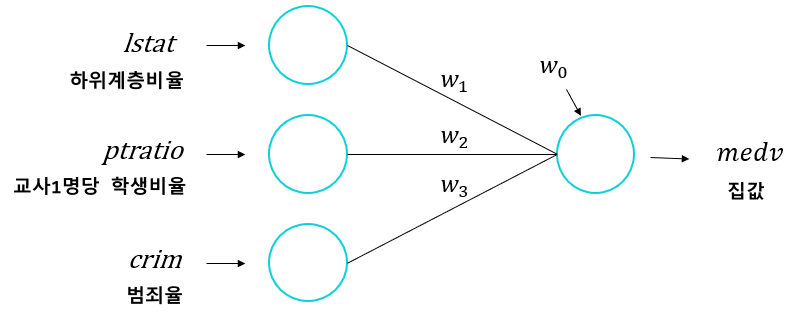

### (1) 데이터 준비
* x, y 나누기
    * x : lstat, ptratio, crim
    * y : medv

In [9]:
target = 'medv'
features = ['lstat', 'ptratio', 'crim']
x = data.loc[:, features]
y = data.loc[:, target]

### (2) 가변수화

### (3) 데이터분할

In [10]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=.2, random_state = 20)

### (4) Scaling

In [11]:
# 스케일러 선언
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)

## **3.모델링1 : feature 3개**

### (1) 딥러닝을 위한 준비작업

* make_DataLoader
    * train : 미니 배치 처리를 위한 데이터 로더로 만들기
    * val : 검증셋으로 성능 측정하면 되므로 텐서 그대로 사용

In [12]:
train_loader, x_val_ts, y_val_ts = make_DataSet(x_train, x_val, y_train, y_val, 32)

In [13]:
# 첫번째 배치만 로딩해서 살펴보기
for x, y in train_loader:
    print(f"Shape of x [rows, columns]: {x.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of x [rows, columns]: torch.Size([32, 3])
Shape of y: torch.Size([32, 1]) torch.float32


### (2) 모델 선언

* nn.Linear(입력, 출력) 레이어 한개를 추가해 봅시다.
    * [출력] 층의 **노드 수** 입니다.

In [14]:
x.shape[1]

3

In [15]:
n_feature = x.shape[1]

# 모델 구조 설계
model1 = nn.Sequential(
    nn.Linear(n_feature, 1)
        ).to(device)

print(model1)

Sequential(
  (0): Linear(in_features=3, out_features=1, bias=True)
)


* Loss function과 Optimizer
    * loss function : MSE
    * Optimizer : Adam(모델 파라미터, 학습률)

In [16]:
loss_fn = nn.MSELoss()
optimizer = Adam(model1.parameters(), lr = 0.1)

### (3) 학습

In [17]:
epochs = 50
tr_loss_list, val_loss_list = [], []

for t in range(epochs):
    tr_loss = train(train_loader, model1, loss_fn, optimizer, device)
    val_loss, _ = evaluate(x_val_ts, y_val_ts, model1, loss_fn, device)

    # 리스트에 loss 추가 --> learning curve 그리기 위해.
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

Epoch 1, train loss : 539.015564, val loss : 416.663818
Epoch 2, train loss : 447.917969, val loss : 336.559662
Epoch 3, train loss : 372.162048, val loss : 272.648590
Epoch 4, train loss : 311.454651, val loss : 224.371521
Epoch 5, train loss : 268.349823, val loss : 188.110474
Epoch 6, train loss : 240.560547, val loss : 162.367325
Epoch 7, train loss : 212.841080, val loss : 144.071655
Epoch 8, train loss : 190.667892, val loss : 130.693283
Epoch 9, train loss : 182.118057, val loss : 121.465103
Epoch 10, train loss : 170.236832, val loss : 114.508141
Epoch 11, train loss : 164.072357, val loss : 109.610580
Epoch 12, train loss : 154.808472, val loss : 105.488914
Epoch 13, train loss : 151.056503, val loss : 101.988533
Epoch 14, train loss : 144.499313, val loss : 98.820847
Epoch 15, train loss : 140.015884, val loss : 95.957848
Epoch 16, train loss : 137.041473, val loss : 93.536026
Epoch 17, train loss : 130.745026, val loss : 90.994072
Epoch 18, train loss : 132.172272, val loss 

* 학습된 파라미터 확인

In [18]:
for name, param in model1.named_parameters():
    if param.requires_grad:
        print(f"Parameter: {name}, Value: {param.data}")

Parameter: 0.weight, Value: tensor([[-14.6155,   6.6033, -22.4445]])
Parameter: 0.bias, Value: tensor([23.0592])


In [ ]:
# ['lstat', 'ptratio', 'crim']

* 학습 곡선

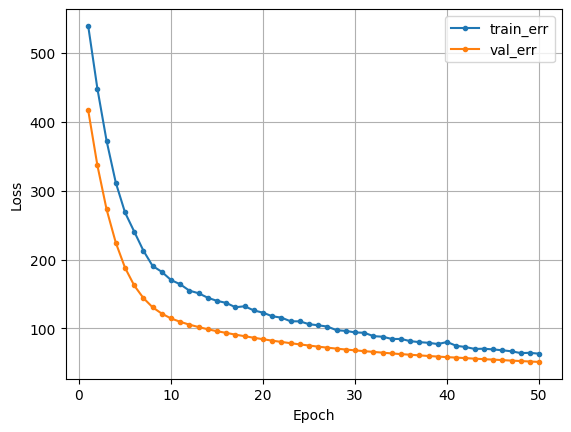

In [19]:
dl_learning_curve(tr_loss_list, val_loss_list)

### (4) 모델 평가

In [20]:
loss, pred = evaluate(x_val_ts, y_val_ts, model1, loss_fn, device)
print(f'MSE : {loss}')

MSE : 51.40571212768555


* 평가 추가 : MAE, MAPE

In [22]:
mae = mean_absolute_error(y_val_ts.numpy(), pred.numpy())
mape = mean_absolute_percentage_error(y_val_ts.numpy(), pred.numpy())
print(f'MAE : {mae}') # 평균 오차
print(f'MAPE : {mape}') # 평균 오차율

MAE : 5.070028781890869
MAPE : 0.2456343173980713


## **4.모델링2 : feature 전체**
* 이제 전체 데이터를 가지고 모델링을 시도해 보겠습니다.


### (1) 데이터 전처리

* 데이터 분할

In [23]:
target = 'medv'
x = data.drop(target, axis = 1)
y = data.loc[:, target]
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=.2, random_state = 20)

* 스케일링

In [24]:
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)

### (2) 모델링

* make_DataLoader

In [25]:
train_loader, x_val_ts, y_val_ts = make_DataSet(x_train, x_val, y_train, y_val)

* 모델 설계

In [26]:
n_feature = x.shape[1]

# 모델 구조 설계
model2 = nn.Sequential(
    nn.Linear(n_feature, 1)
                       ).to(device)

print(model2)

Sequential(
  (0): Linear(in_features=12, out_features=1, bias=True)
)


* Loss function과 Optimizer

In [27]:
loss_fn = nn.MSELoss()
optimizer = Adam(model2.parameters(), lr = 0.1)

### (3) 학습

In [30]:
epochs = 50
tr_loss_list, val_loss_list = [], []

for t in range(epochs):
    tr_loss = train(train_loader, model2, loss_fn, optimizer, device)
    val_loss, _ = evaluate(x_val_ts, y_val_ts, model2, loss_fn, device)

    # 리스트에 loss 추가 --> learning curve 그리기 위해.
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

Epoch 1, train loss : 294.715637, val loss : 181.875046
Epoch 2, train loss : 200.699936, val loss : 133.873703
Epoch 3, train loss : 160.904114, val loss : 117.010941
Epoch 4, train loss : 145.773743, val loss : 105.572014
Epoch 5, train loss : 130.939682, val loss : 94.172737
Epoch 6, train loss : 119.626602, val loss : 84.376678
Epoch 7, train loss : 105.973152, val loss : 76.274864
Epoch 8, train loss : 98.103477, val loss : 69.418327
Epoch 9, train loss : 91.702179, val loss : 63.952053
Epoch 10, train loss : 83.006599, val loss : 60.044468
Epoch 11, train loss : 77.050507, val loss : 56.510082
Epoch 12, train loss : 72.780151, val loss : 53.286701
Epoch 13, train loss : 69.864433, val loss : 51.054947
Epoch 14, train loss : 66.057579, val loss : 49.041039
Epoch 15, train loss : 63.260452, val loss : 47.513622
Epoch 16, train loss : 63.588486, val loss : 46.093559
Epoch 17, train loss : 59.798409, val loss : 45.032276
Epoch 18, train loss : 58.182007, val loss : 44.259892
Epoch 19

* 학습된 파라미터 확인

In [31]:
for name, param in model2.named_parameters():
    if param.requires_grad:
        print(f"Parameter: {name}, Value: {param.data}")

Parameter: 0.weight, Value: tensor([[-9.6060e+00,  6.8731e+00, -1.9607e-02,  5.5620e+00,  1.3992e+00,
          1.8169e+01,  6.7492e+00,  5.2718e+00,  5.7989e-01, -2.9728e+00,
          2.8269e-03, -1.7173e+01]])
Parameter: 0.bias, Value: tensor([12.1499])


* 학습 곡선

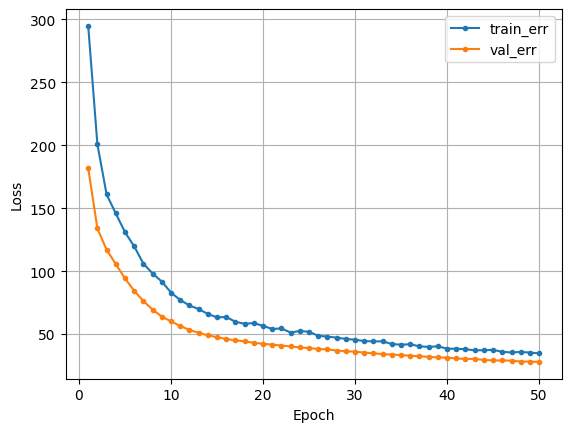

In [32]:
dl_learning_curve(tr_loss_list, val_loss_list)

### (4) 모델 평가

In [33]:
loss, pred = evaluate(x_val_ts, y_val_ts, model2, loss_fn, device)

mae = mean_absolute_error(y_val_ts.numpy(), pred.numpy())
mape = mean_absolute_percentage_error(y_val_ts.numpy(), pred.numpy())

print(f'MSE : {loss}')
print(f'MAE : {mae}')
print(f'MAPE : {mape}')

MSE : 27.912185668945312
MAE : 4.0995635986328125
MAPE : 0.20700664818286896


## **5.모델링3 : 은닉층 추가**

### (1) 데이터 전처리
4.모델링2 에서 준비한 데이터를 이용합니다.

### (2) 모델링
4.모델링2 에서 선언한 DataLoader를 그대로 사용합니다.

* 모델 설계

In [34]:
n_feature = x.shape[1]

# 모델 구조 설계
model3 = nn.Sequential(
            nn.Linear(n_feature, 2),
            nn.ReLU(),
            nn.Linear(2, 1),
        ).to(device)

print(model3)

Sequential(
  (0): Linear(in_features=12, out_features=2, bias=True)
  (1): ReLU()
  (2): Linear(in_features=2, out_features=1, bias=True)
)


* Loss function과 Optimizer

In [35]:
loss_fn = nn.MSELoss()
optimizer = Adam(model3.parameters(), lr = 0.1)

### (3) 학습

In [57]:
epochs = 500
tr_loss_list, val_loss_list = [], []

for t in range(epochs):
    tr_loss = train(train_loader, model3, loss_fn, optimizer, device)
    val_loss, _ =  evaluate(x_val_ts, y_val_ts, model3, loss_fn, device)

    # 리스트에 loss 추가 --> learning curve 그리기 위해.
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

Epoch 1, train loss : 14.289161, val loss : 14.433016
Epoch 2, train loss : 14.534317, val loss : 15.038124
Epoch 3, train loss : 15.212107, val loss : 14.392525
Epoch 4, train loss : 14.105611, val loss : 14.693306
Epoch 5, train loss : 14.495210, val loss : 17.171057
Epoch 6, train loss : 15.355973, val loss : 16.407337
Epoch 7, train loss : 15.269489, val loss : 14.647254
Epoch 8, train loss : 13.987924, val loss : 15.441722
Epoch 9, train loss : 14.122844, val loss : 17.937588
Epoch 10, train loss : 14.528893, val loss : 14.741081
Epoch 11, train loss : 14.053391, val loss : 14.770179
Epoch 12, train loss : 14.516226, val loss : 15.798923
Epoch 13, train loss : 15.106115, val loss : 15.562195
Epoch 14, train loss : 15.340260, val loss : 15.634142
Epoch 15, train loss : 16.300508, val loss : 17.948690
Epoch 16, train loss : 17.301023, val loss : 18.413357
Epoch 17, train loss : 14.287416, val loss : 14.325445
Epoch 18, train loss : 14.750525, val loss : 14.168316
Epoch 19, train los

* 학습된 파라미터 확인

In [58]:
for name, param in model3.named_parameters():
    if param.requires_grad:
        print(f"Parameter: {name}, Value: {param.data}")

Parameter: 0.weight, Value: tensor([[-8.3435e+00, -1.7850e-01,  1.3119e+00,  4.0610e-01, -3.6035e+00,
          4.4893e+00, -3.7832e-01, -2.1713e+00,  1.9959e+00, -3.4706e+00,
         -3.0613e+00, -8.1077e+00],
        [-2.0536e-02,  2.0863e+00, -2.8328e+00,  3.2408e-01, -5.0597e-01,
          8.2509e+00,  1.5264e+00, -9.2365e+00,  7.5272e+00,  3.7101e-01,
         -2.2846e+00, -3.1537e+01]])
Parameter: 0.bias, Value: tensor([10.9682,  2.7846])
Parameter: 2.weight, Value: tensor([[1.6537, 2.0488]])
Parameter: 2.bias, Value: tensor([10.3382])


* 학습 곡선

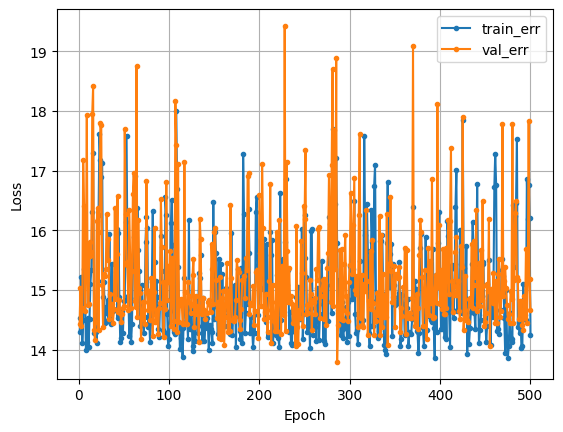

In [59]:
dl_learning_curve(tr_loss_list, val_loss_list)

### (4) 모델 평가

In [60]:
loss, pred = evaluate(x_val_ts, y_val_ts, model3, loss_fn, device)

mae = mean_absolute_error(y_val_ts.numpy(), pred.numpy())
mape = mean_absolute_percentage_error(y_val_ts.numpy(), pred.numpy())

print(f'MSE : {loss}')
print(f'MAE : {mae}')
print(f'MAPE : {mape}')

MSE : 14.658854484558105
MAE : 2.897540330886841
MAPE : 0.1553623378276825


## **6.실습1**
* 여러분은 다음의 구조대로 모델링을 수행하고 성능평가를 해 봅시다.
    * 모델 구조
            Sequential(
              (0): Linear(in_features=12, out_features=10, bias=True)
              (1): ReLU()
              (2): Linear(in_features=10, out_features=5, bias=True)
              (3): ReLU()
              (4): Linear(in_features=5, out_features=1, bias=True)
            )
    * epochs(반복횟수) : 100
    * lr(learning rate, 학습률) : 0.01

* 모델 설계

In [61]:
n_feature = x.shape[1]

model4 = nn.Sequential(
    nn.Linear(n_feature, 10),
    nn.ReLU(),
    nn.Linear(10, 5),
    nn.ReLU(),
    nn.Linear(5, 1)
).to(device)

print(model4)

Sequential(
  (0): Linear(in_features=12, out_features=10, bias=True)
  (1): ReLU()
  (2): Linear(in_features=10, out_features=5, bias=True)
  (3): ReLU()
  (4): Linear(in_features=5, out_features=1, bias=True)
)


* Loss function과 Optimizer

In [ ]:
loss_fn = nn.MSELoss()
optimizer = Adam(model4.parameters(), lr = 0.01)

* 학습

In [62]:
epochs = 100
tr_loss_list, val_loss_list = [], []

for t in range(epochs):
    tr_loss = train(train_loader, model4, loss_fn, optimizer, device)
    val_loss, _ = evaluate(x_val_ts, y_val_ts, model4, loss_fn, device)

    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

Epoch 1, train loss : 623.238647, val loss : 547.858215
Epoch 2, train loss : 628.600037, val loss : 547.858215
Epoch 3, train loss : 621.404907, val loss : 547.858215
Epoch 4, train loss : 626.959534, val loss : 547.858215
Epoch 5, train loss : 623.004822, val loss : 547.858215
Epoch 6, train loss : 620.708740, val loss : 547.858215
Epoch 7, train loss : 619.813538, val loss : 547.858215
Epoch 8, train loss : 617.065613, val loss : 547.858215
Epoch 9, train loss : 625.159180, val loss : 547.858215
Epoch 10, train loss : 628.489746, val loss : 547.858215
Epoch 11, train loss : 623.073608, val loss : 547.858215
Epoch 12, train loss : 624.518921, val loss : 547.858215
Epoch 13, train loss : 618.229736, val loss : 547.858215
Epoch 14, train loss : 624.380127, val loss : 547.858215
Epoch 15, train loss : 620.906433, val loss : 547.858215
Epoch 16, train loss : 627.307373, val loss : 547.858215
Epoch 17, train loss : 620.847961, val loss : 547.858215
Epoch 18, train loss : 619.478394, val l

* 학습 곡선

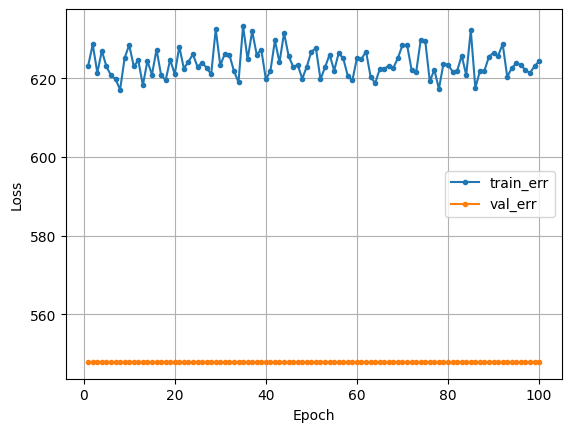

In [63]:
dl_learning_curve(tr_loss_list, val_loss_list)

* 모델 평가 : MSE

In [64]:
loss, pred = evaluate(x_val_ts, y_val_ts, model4, loss_fn, device)

mae = mean_absolute_error(y_val_ts.numpy(), pred.numpy())
mape = mean_absolute_percentage_error(y_val_ts.numpy(), pred.numpy())

print(f'MSE : {loss}')
print(f'MAE : {mae}')
print(f'MAPE : {mape}')

MSE : 547.8582153320312
MAE : 21.98672103881836
MAPE : 1.0194708108901978


## **7.실습2**
* 이번에는 여러분이 원하는 구조와 하이퍼파라미터 값을 조정하여 성능을 높여 봅시다.

* 모델 설계

* Loss function과 Optimizer

* 학습

* 학습 곡선

* 모델 평가 : MSE